Running in local mode. Total devices: 1
0.5 0.5


(0.1, 1)

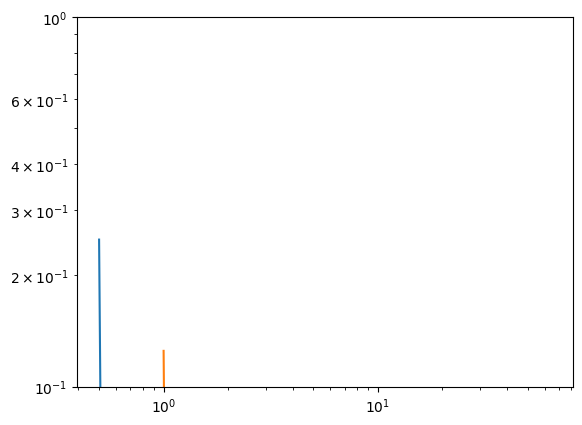

In [97]:
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
import os
import jax_rmhd.snapshot_io as sn
import jax_rmhd.diagnostics as diag
jr.init_cluster()

#parameters
nx = 128
ny = 128
nz = 128
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap = 1.0
t_end = 6.0
cfl_safety = 1.0 #this is pretty aggressive
spatial_dimensions=3
snap_path="data/orzag-tang-3D/"

#we will use hyperviscosity
visc=1e-8
res=1e-8
hyper=3


def perpspec(phik,psik,kgrid,params,bin_factor=2.0):
    rfft2_y_factor = jnp.full(phik.shape[-1],2.0)
    rfft2_y_factor = rfft2_y_factor.at[0].set(1.0)
    rfft2_y_factor = rfft2_y_factor.at[-1].set(1.0)
    energy_u = 0.5 * kgrid.ksq() * jnp.abs(phik)**2.0 * rfft2_y_factor
    energy_b = 0.5 * kgrid.ksq() * jnp.abs(psik)**2.0 * rfft2_y_factor
    if params.spatial_dimensions==3:
        energy_u = jnp.sum(energy_u,axis=0)/params.nz
        energy_b = jnp.sum(energy_b,axis=0)/params.nz
    kunit = min(2 * jnp.pi / params.Lx, 2 * jnp.pi / params.Ly)
    kmax = min(params.nx//2,params.ny//2)*kunit
    dk=kunit*bin_factor
    bin_edges = jnp.arange(0,kmax+dk,dk)
    norm = 1 / float(params.nx*params.ny)**2
    spec_u=[]
    spec_b=[]
    for ib in range(len(bin_edges)-1):
        cond=(bin_edges[ib]<jnp.sqrt(kgrid.ksq()))*(jnp.sqrt(kgrid.ksq())<=bin_edges[ib+1])
        spec_u.append(jnp.sum(energy_u * cond))
        spec_b.append(jnp.sum(energy_b * cond))

    spec_u = jnp.array(spec_u) * norm /dk
    spec_b = jnp.array(spec_b) * norm /dk
    #spec_u, _ = jnp.histogram(jnp.sqrt(kgrid.ksq()),bins=bins,weights=energy_u*norm)
    #spec_b, _ = jnp.histogram(jnp.sqrt(kgrid.ksq()),bins=bins,weights=energy_b*norm)
    bin_centers=(bin_edges[1:] + bin_edges[:-1]) / 2
    return bin_centers,spec_u,spec_b

def perpspec2(phik,psik,kgrid,params,bin_factor=2.0):
    rfft2_y_factor = jnp.full(phik.shape[-1],2.0)
    rfft2_y_factor = rfft2_y_factor.at[0].set(1.0)
    rfft2_y_factor = rfft2_y_factor.at[-1].set(1.0)
    energy_u = 0.5 * kgrid.ksq() * jnp.abs(phik)**2.0 * rfft2_y_factor
    energy_b = 0.5 * kgrid.ksq() * jnp.abs(psik)**2.0 * rfft2_y_factor
    if params.spatial_dimensions==3:
        energy_u = jnp.sum(energy_u,axis=0)/params.nz
        energy_b = jnp.sum(energy_b,axis=0)/params.nz
    kunit = min(2 * jnp.pi / params.Lx, 2 * jnp.pi / params.Ly)
    kmax = min(params.nx//2,params.ny//2)*kunit
    dk=kunit*bin_factor
    bin_edges = jnp.arange(0,kmax+dk,dk)
    norm = 1 / float(params.nx*params.ny)**2
    spec_u, _ = jnp.histogram(jnp.sqrt(kgrid.ksq()),bins=bin_edges,weights=energy_u*norm/dk)
    spec_b, _ = jnp.histogram(jnp.sqrt(kgrid.ksq()),bins=bin_edges,weights=energy_b*norm/dk)
    #spec_u, _ = jnp.histogram(jnp.sqrt(kgrid.ksq()),bins=bins,weights=energy_u*norm)
    #spec_b, _ = jnp.histogram(jnp.sqrt(kgrid.ksq()),bins=bins,weights=energy_b*norm)
    bin_centers=(bin_edges[1:] + bin_edges[:-1]) / 2
    return bin_centers,spec_u,spec_b

def parspec(phik,psik,kgrid,params,bin_factor=2.0):
    rfft2_y_factor = jnp.full(phik.shape[-1],2.0)
    rfft2_y_factor = rfft2_y_factor.at[0].set(1.0)
    rfft2_y_factor = rfft2_y_factor.at[-1].set(1.0)
    #phik = state.fields.phik
    #psik = state.fields.psik
    phikkz = ft.fft(phik,axis=0)
    psikkz = ft.fft(psik,axis=0)
    kz = ft.rfftfreq(params.nz) * params.nz * 2 * jnp.pi / params.Lz
    en_u_full = jnp.sum(0.5 * kgrid.ksq() * jnp.abs(phikkz)**2.0 * rfft2_y_factor, axis=(1,2))
    en_b_full = jnp.sum(0.5 * kgrid.ksq() * jnp.abs(psikkz)**2.0 * rfft2_y_factor, axis=(1,2))
    half = params.nz // 2
    energy_u = en_u_full[:half+1].at[1:half].add(en_u_full[half+1:][::-1])
    energy_b = en_b_full[:half+1].at[1:half].add(en_b_full[half+1:][::-1])
    kunit = 2 * jnp.pi / params.Lz
    kmax = params.nz//2 * kunit
    dk=kunit*bin_factor
    bin_edges = jnp.arange(0,kmax+dk,dk)
    norm= 1.0 /dk/float(params.nx*params.ny*params.nz)**2
    spec_u, _ = jnp.histogram(kz,bins=bin_edges,weights=energy_u*norm)
    spec_b, _ = jnp.histogram(kz,bins=bin_edges,weights=energy_b*norm)
    bin_centers=(bin_edges[1:] + bin_edges[:-1]) / 2
    return bin_centers,spec_u,spec_b


x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
z = jnp.linspace(0, Lz, nz, endpoint=False)

x_grid = x.reshape(1,-1,1)
y_grid = y.reshape(1,1,-1)
z_grid = z.reshape(-1,1,1)

phi = jnp.cos(x_grid) + jnp.zeros_like(y_grid) + jnp.zeros_like(z_grid)
#phi = (jnp.cos(x_grid+1.4) + jnp.cos(y_grid+0.5)) * jnp.sin(z_grid)
phik=ft.rfft2(phi)
phikkz=ft.fft(phik,axis=0)

params=jr.Parameters(nx=nx,ny=ny,nz=nz,Lx=Lx,Ly=Ly,Lz=Lz,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
shardings=jr.setup_sharding(params)
kgrid = jr.setup_kgrids(params)

weights=jnp.full(phik.shape[-1],2.0)
weights = weights.at[0].set(1.0)
weights = weights.at[-1].set(1.0)
print(jnp.sum(phi**2)/nx/ny/nz,jnp.sum(jnp.abs(phikkz)**2 * weights /nx**2/ny**2/nz**2))
bins,su,sb=perpspec(phik,phik,kgrid,params,bin_factor=1)
plt.loglog(bins,su)
bins2,su2,sb2=perpspec(phik,phik,kgrid,params,bin_factor=2)
plt.loglog(bins2,su2)
plt.ylim(1e-1,1)

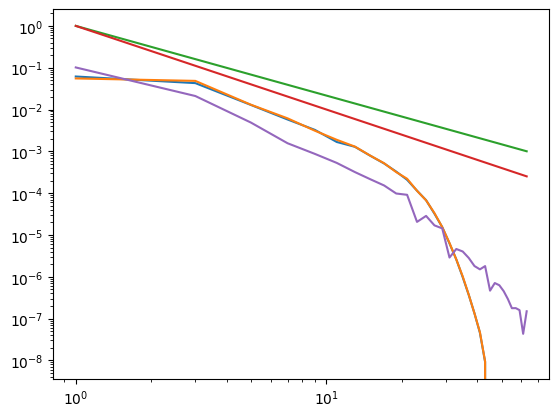

In [99]:
mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

sk=sn.load_snapshot(6,mngr,params,shardings)
phik=sk.fields.phik
bins,su,sb=perpspec(phik,phik,kgrid,params,bin_factor=2)
plt.loglog(bins,su)
bins2,su2,sb=perpspec2(phik,phik,kgrid,params,bin_factor=2)
plt.loglog(bins2,su2)
plt.loglog(bins,bins**(-5/3))
plt.loglog(bins,bins**(-2))
binspar,supar,sbpar=parspec(phik,phik,kgrid,params,bin_factor=2)
plt.loglog(binspar,supar)

In [83]:
bins2==bins

Array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True], dtype=bool)

In [84]:
su,su2

(Array([6.71312601e-02, 5.60068189e-02, 6.22898213e-02, 2.32884444e-02,
        1.63504628e-02, 9.37461197e-03, 6.21924030e-03, 5.33119703e-03,
        3.81400938e-03, 2.70032403e-03, 1.93982725e-03, 1.40940647e-03,
        1.37555689e-03, 1.19147370e-03, 9.16603632e-04, 6.42285184e-04,
        5.79692689e-04, 4.44910894e-04, 3.69581449e-04, 2.84630375e-04,
        2.14922385e-04, 2.02236934e-04, 1.32505348e-04, 9.66103856e-05,
        7.87720027e-05, 5.69822806e-05, 3.94635319e-05, 2.50764765e-05,
        1.84124993e-05, 1.24140161e-05, 7.35362864e-06, 5.21328692e-06,
        3.15752225e-06, 2.05362881e-06, 1.28461010e-06, 6.77951717e-07,
        4.82742654e-07, 2.53421783e-07, 1.70040751e-07, 9.68693811e-08,
        5.51752345e-08, 3.62619357e-08, 1.84589984e-08, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.000000